In [1]:
import os
from Scope.Read_Write import load_binary

In [2]:
## In this tutorial, we will compute the thermodynamic properties for the b3lpy_opt state, which includes the vibrational normal modes  
## Also, we will discuss the DATA class, which is a very basic class that is used to store results

In [3]:
## As usual, we first load the System object from a binary file
sys = load_binary(os.path.abspath('.')+'/Sources/ABITEM.npy')

## Then, we select the source 
found, source = sys.find_source("ref_hs_mol")

## And the state
found, final_state = source.find_state("b3lyp_opt")
print(final_state)

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = b3lyp_opt
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.774774, 3.779086, 13.494815]...
 Is Minimum            = True



## Vibrational Normal Modes (VNMs)

In [4]:
## Notice that the state is a minimum energy structure:
print(final_state.isminimum)

True


In [5]:
## This is because the user provided the VNM. Here's the first one
print(final_state.VNMs[0])

-----------------------------
   Vibrational Normal Mode   
-----------------------------
 Index                  = 1
 Freq (cm-1)            = 21.6469
 IR Intensity (KM/Mole) = 1.0847
 Reduced Mass (AMU)     = 14.2624
 Has Mode               = False



In [6]:
# By default, the eigenvectors of the VNMs are not stored... 
print(final_state.VNMs[0].has_mode)

False


In [7]:
# ... but they can be parsed if needed. To do it:
freq_comp = final_state.computations[-1]                                       ## Select the computation
freq_comp.out_path = os.path.abspath('.')+'/Sources/ABITEM_freq_r1_HS.log'     ## Modify is original path to re-read it

# And parse the frequencies
from Scope.Register_Data import reg_frequencies
worked = reg_frequencies(freq_comp, witheigen=True)
print(final_state.VNMs[0].has_mode)

True


## Thermodynamic Properties

In [8]:
# Because the state contains the VNMs, we can compute the Thermodynamic Properties:
final_state.get_thermal_data()

In [9]:
# The above function computes the vibrational enthalpy (Hvib) and entropy (Svib), as defined in the manuscript. 
# These, together with the electronic enthalpy (Helec) and entropy (Selec) are used to compute the Gibbs Free Energy (Gtot)
print(final_state.results["Helec"])
print(final_state.results["Selec"])


Helec: -3159.62579289 au
Selec:   0.00000510 au


In [10]:
# Notice that Helec and Selec are just a single instance of a so called DATA-class.
final_state.results["Helec"].type

'data'

In [11]:
# The DATA class forces the results to be stored together with the units, and the function where they're computed.
print(final_state.results["Helec"].value)
print(final_state.results["Helec"].units)
print(final_state.results["Helec"].function)

-3159.62579289
au
state.get_thermal_data()


In [12]:
# In turn, Hvib, Svib and Gtot are a so-called COLLECTION class. This class gathers several data entries into a single instance 
print(final_state.results["Hvib"])
print(final_state.results["Svib"])
print(final_state.results["Gtot"])

---------------------------------------------------
   COLLECTION OF DATA   = Hvib                
---------------------------------------------------
 Variable              = Temperature
 #Entries              = 491
 First                 = 0.35192142594527903
 Last                  = 0.41498711454900233
 Units                 = au
 Function              = Scope.Thermal_Corrections.get_Hvib()

---------------------------------------------------
   COLLECTION OF DATA   = Svib                
---------------------------------------------------
 Variable              = Temperature
 #Entries              = 491
 First                 = 1.346720714505055e-06
 Last                  = 0.00026509997016783504
 Units                 = au
 Function              = Scope.Thermal_Corrections.get_Svib()

---------------------------------------------------
   COLLECTION OF DATA   = Gtot                
---------------------------------------------------
 Variable              = Temperature
 #Entries  

In [13]:
# To retrieve the values out of a COLLECTION class, you can:
print(final_state.results["Hvib"].get_values()[0:10]) # Notice that only the first 10 entries are printed


[0.35192143 0.35192619 0.35193192 0.35193862 0.35194627 0.35195484
 0.35196433 0.35197471 0.35198596 0.35199809]


In [14]:
# Again, units and the used function are specified:
print(final_state.results["Hvib"].units)
print(final_state.results["Hvib"].function)
# Also, what is the variable that changes within the collection:
print(final_state.results["Hvib"].variable)

au
Scope.Thermal_Corrections.get_Hvib()
Temperature


In [15]:
# To access an individual entry, you can search by the name of variable, and its value
final_state.results["Hvib"].find_value_with_property("temperature", 200)

Hvib:   0.36348555 au

### Subtracting Collections

In [16]:
# Collections can be subtracted:
HS_state = final_state # we were operating with the HS molecule's data

## Lets select the LS as well, and compute its TD properties 
found, source   = sys.find_source("ref_ls_mol")
found, LS_state = source.find_state("b3lyp_opt")
LS_state.get_thermal_data()

print(HS_state)
print(LS_state)

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = b3lyp_opt
 Source Name           = ref_hs_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [3.774774, 3.779086, 13.494815]...
 Number of Complexes   = 1
 Is Minimum            = True
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C20-N6-S2-Fe 

---------------------------------------------------
   STATE                                           
---------------------------------------------------
 Name                  = b3lyp_opt
 Source Name           = ref_ls_mol
 Source Type           = specie
 Labels                = Fe...
 Coord                 = [4.171778, 7.781139, 4.158969]...
 Number of Complexes   = 1
 Is Minimum            = True
 # Molecules:          = 1
 With Formulae:                               
    0: H18-C2

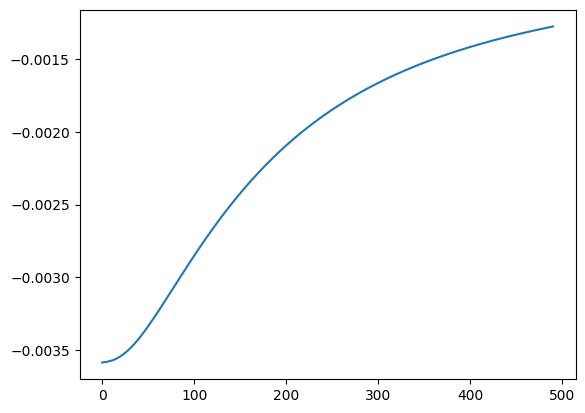

In [17]:
# Collections to substract
HS_Hvib = HS_state.results["Hvib"]
LS_Hvib = LS_state.results["Hvib"]

# New collection:
dHvib = HS_Hvib - LS_Hvib

# Collections can be plotted
dHvib.view()

## Units Conversion

In [18]:
## A very basic system to change units has been implemented at the DATA class level (not for collections).
print(final_state.results["Helec"])

## print_in_units() will preserve the original units:
print(final_state.results["Helec"].print_in_units("ev"))
print(final_state.results["Helec"])

## Convert to units function will overwrite the DATA units permanently:
print(final_state.results["Helec"].convert_to_units("cm"))
print(final_state.results["Helec"])

Helec: -3159.62579289 au
Helec: -85977.83814102 ev
Helec: -3159.62579289 au
Helec: -693457607.04421556 cm
Helec: -693457607.04421556 cm
